In [1]:
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import warnings
import numpy as np
from plots import *
np.seterr(over='ignore')
sns.set_style("whitegrid")

# Font sizes
LABEL_FONTSIZE = 6
TICK_FONTSIZE = 6
LEGEND_FONTSIZE = 6

# Figure size
FIGSIZE = (3, 2)

# Line plot parameters
MARKERSIZE = 5
LINEWIDTH = 0.8
ALPHA = 1.0

# Spine and tick parameters
SPINE_WIDTH = 0.7
SPINE_COLOR = 'gray'
TICK_COLOR = 'black'

# Grid parameters
GRID_ALPHA = 0.1
GRID_LINESTYLE = '--'
GRID_LINEWIDTH = 0.5

PALETTE_FULL = plt.cm.tab10.colors
#PALETTE = [PALETTE_FULL[7], PALETTE_FULL[8], PALETTE_FULL[9]]
PALETTE = plt.cm.tab10.colors

In [ ]:
cell_info = [
    {"id": 0, "description": "Immune"},
    {"id": 1, "description": "Str"},
    {"id": 2, "description": "Pod"},
    {"id": 3, "description": "CD"},
    {"id": 4, "description": "PE"},
    {"id": 5, "description": "Tcell"},
    {"id": 6, "description": "End"},
    {"id": 7, "description": "DT"},
    {"id": 8, "description": "PT"},
    {"id": 9, "description": "LOH"},
]
def plot_roc_pr_cells(labels_all, sad_all, cell_info, suptitle=None, save_pdf=False, filename='test'):
   
    colors = plt.cm.tab10.colors 
    fontsize = 5
    
    # Define color mapping for each cell type
    cell_colors = {
        'Immune': colors[0],
        'Str': colors[1],
        'Pod': colors[2],
        'CD': colors[3],
        'PE': colors[4],
        'Tcell': colors[5],
        'End': colors[6],  # Changed from 'END' to 'End' to match your cell_info
        'DT': colors[7],
        'PT': colors[8],
        'LOH': colors[9]
    }
    
    metrics = []
    for cell in cell_info:
        scores = sad_all[:, cell['id']]
        fpr, tpr, _ = roc_curve(labels_all, scores)
        roc_auc = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(labels_all, scores)
        auprc = auc(recall, precision)
        metrics.append({
            "cell": cell,
            "roc_auc": roc_auc,
            "auprc": auprc,
            "fpr": fpr,
            "tpr": tpr,
            "recall": recall,
            "precision": precision
        })
    
    # Sort metrics by AUROC and AUPRC separately
    metrics_roc_sorted = sorted(metrics, key=lambda x: x['roc_auc'], reverse=True)
    metrics_pr_sorted = sorted(metrics, key=lambda x: x['auprc'], reverse=True)
    
    plt.figure(figsize=(6, 2.5))
    
    # ROC subplot
    plt.subplot(1, 2, 1)
    for m in metrics_roc_sorted:
        cell_desc = m['cell']['description']
        color = cell_colors[cell_desc]  # Use the fixed color for this cell type
        plt.plot(m['fpr'], m['tpr'], color=color, 
                label=f"{cell_desc} ({m['roc_auc']:.2f})")
    plt.plot([0, 1], [0, 1], color='gray', alpha=0.3, linestyle='--', linewidth=0.8)
    plt.xlabel('False Positive Rate', fontsize=6)
    plt.ylabel('True Positive Rate', fontsize=6)
    plt.grid(False)
    plt.legend(loc='lower right', frameon=False, fontsize=6)
    ax1 = plt.gca()
    ax1.tick_params(axis='both',
                which='major',
                direction='out',
                bottom=True, top=False,
                left=True, right=False,
                width=0.5,
                colors='black',
                labelsize=6)
    
    for spine in ax1.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color('gray')
    
    # PR subplot
    plt.subplot(1, 2, 2)
    for m in metrics_pr_sorted:
        cell_desc = m['cell']['description']
        color = cell_colors[cell_desc]  # Use the fixed color for this cell type
        plt.plot(m['recall'], m['precision'], color=color, 
                label=f"{cell_desc} ({m['auprc']:.2f})")
    plt.xlabel('Recall', fontsize=6)
    plt.ylabel('Precision', fontsize=6)
    plt.grid(False)
    plt.legend(loc='upper right', frameon=False, fontsize=6)
    ax2 = plt.gca()
    
    ax2.tick_params(axis='both',
                which='major',
                direction='out',
                bottom=True, top=False,
                left=True, right=False,
                width=0.5,
                colors='black',
                labelsize=6)
    for spine in ax2.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color('gray')
    
    if suptitle:
        plt.suptitle(suptitle, fontsize=6)
    
    plt.tight_layout()
    
    if save_pdf:
        plt.savefig(f'{filename}.pdf', bbox_inches='tight')
        print(f"Saved figure as {filename}")
    
    plt.show()



cell_id=9
def clip_float(x, dtype=np.float16):
    return np.clip(x, np.finfo(dtype).min, np.finfo(dtype).max)


def compute_sad(pos_sad, neg_sad, pos_index, model='borzoi'):

    if model == 'enformer':
        bins = 8
    elif model == 'borzoi_ensemble':
        bins= 32
    elif model == 'borzoi_rep':
        bins=32
    elif model == 'chromkid':
        bins=1
    elif model == 'kidzoi':
        bins=32
    elif model == 'kidformer':
        bins=8
    elif model == 'borzoifinetunedensemble':
        bins=32
    elif model == 'alphagenome':
        bins=8
    
    if model=='sei':
        sad_pos = pos_sad['SAD']
        sad_pos = sad_pos[pos_index]
        sad_neg = neg_sad['SAD'][:]
        sad = np.abs(np.concatenate([sad_pos, sad_neg]))
        labels = np.concatenate([np.ones(sad_pos.shape[0]), np.zeros(sad_neg.shape[0])])
        targets = pos_sad['target_labels']
        targets_df = pd.DataFrame({
            'index': np.arange(len(targets)),
            'description': targets
        })
    
    
    
    else:
        total_bins = pos_sad['REF'].shape[1]
        center = total_bins // 2
        index1 = center - (bins // 2)
        index2 = center + (bins//2)
        pos_ref = clip_float(np.sum(pos_sad['REF'][:, index1:index2, :], axis=1))
        pos_alt = clip_float(np.sum(pos_sad['ALT'][:, index1:index2, :], axis=1))
        sad_pos_raw = pos_alt - pos_ref
        pos_index = np.array(pos_index)
        sad_pos = sad_pos_raw[pos_index]
    
        # Negatives
        neg_ref = clip_float(np.sum(neg_sad['REF'][:, index1:index2, :], axis=1))
        neg_alt = clip_float(np.sum(neg_sad['ALT'][:, index1:index2, :], axis=1))
        sad_neg = neg_alt - neg_ref
        #neg_index = np.random.choice(sad_neg.shape[0], size=593, replace=False)
        #sad_neg = sad_neg[neg_index]
       
        sad = np.abs(np.concatenate([sad_pos, sad_neg]))
        labels = np.concatenate([np.ones(sad_pos.shape[0]), np.zeros(sad_neg.shape[0])])
    
       
        targets = pos_sad['target_labels']
        targets_df = pd.DataFrame({
            'index': np.arange(len(targets)),
            'description': targets
        })

    return sad, labels, targets_df
    


def compute_and_plot_metrics(sad_caai, imb_labels, targets, save_path=None):
    
    target_idx = np.array(targets['index'])
    metrics_data = []

    for ti in target_idx:
        imb_preds = sad_caai[:, ti]       
        valid_mask = ~np.isnan(imb_preds) & ~np.isnan(imb_labels)
        imb_preds = imb_preds[valid_mask]
        imb_lbls_clean = imb_labels[valid_mask]

        if len(imb_lbls_clean) == 0 or np.unique(imb_lbls_clean).size < 2:
            continue

        # Compute AUROC
        fpr, tpr, _ = roc_curve(imb_lbls_clean, imb_preds)
        roc_auc = auc(fpr, tpr)

       
        precision, recall, _ = precision_recall_curve(imb_lbls_clean, imb_preds)
        auprc = auc(recall, precision)
        
        legend_label = targets.loc[targets['index'] == ti, 'description'].values[0]
        

        metrics_data.append({
            'Target Index': ti,
            'Identifier': legend_label,
            'AUROC': roc_auc,
            'AUPRC': auprc
        })

    metrics_df = pd.DataFrame(metrics_data)

    # Save if requested
    if save_path:
        metrics_df.to_csv(save_path, sep='\t', index=False)

    return metrics_df



In [2]:
fine_mapped_dir = "/home/ch263720/Public/arather/kidformer/resources/"
df_finemapped_hg38 = pd.read_csv(f"{fine_mapped_dir}/liftover_new/fine_mapped_variants_hg38.vcf", sep= '\t', header = None)
cols = ['chrom',	'pos',	'variant_id',	'ref',	'alt',	'locus',	'pip',	'pip w/o annotation',	'tubule cre',	'conserved',	'Nonsynonymous']
df_finemapped_hg38.columns = cols

In [4]:
neg = df_finemapped_hg38[df_finemapped_hg38['Nonsynonymous']=='Nonsynonymous']
neg_index = neg.index
pos = df_finemapped_hg38[df_finemapped_hg38['Nonsynonymous']!='Nonsynonymous']
pos_index = pos.index

In [5]:
class_prevalance =593/(len(pos_index) + 3851)
class_prevalance

0.13343834383438344

In [6]:
kidformer_score_dir = "/home/ch263720/Public/arather/kidformer/notes/caai_results/fine_mapped/kidformer/"
chromekid_score_dir = "/home/ch263720/Public/arather/kidformer/notes/caai_results/fine_mapped/chromekid/"
kidzoi_score_dir = "/home/ch263720/Public/arather/kidformer/notes/caai_results/fine_mapped/kidzoi/"
base_models="/home/ch263720/Public/arather/kidformer/notes/caai_results/fine_mapped"


In [8]:
model_dirs = {
    "Borzoi_Ensemble": f"../../caai_results/fine_mapped/borzoi/ensemble/",
    "AlphaGenome": f"../../caai_results/alphagenome/",
    "Enformer": f"../../caai_results/enformer/",
     "Sei": f"../../caai_results/sei/",
 }
models = {}
for name, dir_path in model_dirs.items():
    models[name] = {
        "dir": dir_path,
        "pos": h5py.File(f"{dir_path}/pos/sad.h5", "r"),
        "neg": h5py.File(f"{dir_path}/neg/sad.h5", "r")
    }

In [33]:
%%time
metrics_all = []
for model_name, mdata in models.items():
    caai_score, imb_labels, targets_df = compute_sad(mdata["pos"], mdata["neg"],pos_index, model=model_name.lower())
    metrics_df = compute_and_plot_metrics(
        caai_score,
        imb_labels,
        targets_df
    )
    metrics_df["Model"] = model_name
    metrics_all.append(metrics_df)

metrics_all_df = pd.concat(metrics_all, ignore_index=True)


CPU times: user 2min, sys: 3.73 s, total: 2min 4s
Wall time: 2min 4s


In [14]:
id_clean = metrics_all_df['Identifier'].apply(
    lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else str(x)
)
models_requiring_filter = ['Borzoi_rep','Borzoi_Ensemble', 'Enformer', 'Sei']

keep_mask = (
    ~metrics_all_df['Model'].isin(models_requiring_filter)
) | (
    metrics_all_df['Model'].isin(models_requiring_filter) &
    id_clean.str.contains('dnase|atac', case=False, na=False)
)
filtered_df = metrics_all_df[keep_mask].copy()

rename_map = {
    'sei': 'Sei',
    'Borzoi_Ensemble': 'BorzoiEns',
    'enformer': 'Enformer',
    'Borzoi_rep': 'Borzoi',
    #'EnformerFinetuned': 'EnformerFT'
}

filtered_df['Model'] = filtered_df['Model'].replace(rename_map)


In [4]:
#filtered_df.to_csv("finemapped_with_ag.csv", index = None)
filtered_df = pd.read_csv('../finemapped_with_ag.csv')

In [5]:
filtered_df['Model'].value_counts()

Model
Sei            2528
BorzoiEns       906
Borzoi          906
Enformer        684
AlphaGenome     472
Name: count, dtype: int64

In [6]:
filtered_df[filtered_df['Model'] == 'BorzoiEns'] \
    .sort_values(by='AUROC', ascending=False).head(10)

,Target Index,Identifier,AUROC,AUPRC,Model
844,1482,b'ATAC:Fetal Acinar 1',0.778116,0.428270,BorzoiEns
550,1188,b'DNASE:right kidney male embryo (91 day)',0.778106,0.469546,BorzoiEns
397,1035,b'DNASE:small intestine female embryo (91 day)',0.776536,0.443528,BorzoiEns
334,972,b'DNASE:right kidney male embryo (87 days)',0.770506,0.467637,BorzoiEns
849,1487,b'ATAC:Fetal Alveolar Epithelial 1',0.770127,0.455248,BorzoiEns
440,1078,b'DNASE:left kidney male embryo (115 days)',0.769040,0.464852,BorzoiEns
544,1182,b'DNASE:kidney male embryo (85 days)',0.768668,0.462530,BorzoiEns
865,1503,b'ATAC:Fetal Ductal',0.768543,0.439007,BorzoiEns
473,1111,b'DNASE:left kidney male embryo (87 days)',0.768434,0.458105,BorzoiEns
715,1353,b'ATAC:Fetal Metanephric',0.768224,0.450204,BorzoiEns


In [206]:
filtered_df = filtered_df[filtered_df['Model'] != 'Borzoi']

In [19]:
filtered_df['Model'] = filtered_df['Model'].replace('BorzoiEns', 'Borzoi')

In [20]:
filtered_df[filtered_df['Model']=='Sei']['AUROC'].max(), filtered_df[filtered_df['Model']=='Borzoi']['AUROC'].max()

(0.7865288050715458, 0.7781159314306132)

In [21]:
top_auroc = filtered_df.groupby("Model").apply(
    lambda x: x.nlargest(100, "AUROC")
).reset_index(drop=True)
top_auprc = filtered_df.groupby("Model").apply(
     lambda x: x.nlargest(100, "AUPRC")
 ).reset_index(drop=True)


/tmp/ipykernel_2884656/2752572158.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_auroc = filtered_df.groupby("Model").apply(
/tmp/ipykernel_2884656/2752572158.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_auprc = filtered_df.groupby("Model").apply(


In [23]:
top1_auroc={'BorzoiFT': 0.79,
           'EnformerFT': 0.79,
           'ChromeKid':0.73}

top1_auprc={'BorzoiFT': 0.46,
           'EnformerFT': 0.48,
           'ChromeKid':0.40}

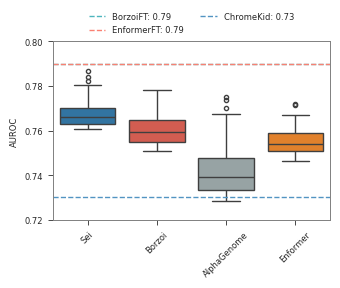

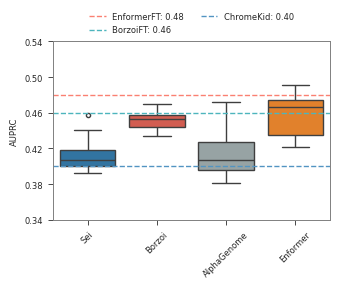

In [25]:
model_order = (
    top_auroc.groupby("Model")["AUROC"]
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)


colors ={"BorzoiFT": "#4DB5BD",
         "EnformerFT":'#FA8072',
         "ChromeKid": '#5294C2'}



box_colors = {
    'Enformer': '#ff7f0e',
    'Sei': '#1f77b4',
    'BorzoiEns': '#8e44ad',
    'Borzoi': '#e74c3c'
}

palette = [box_colors.get(model, '#95a5a6') for model in model_order]

# Create plots

top_auroc_filtered = top_auroc[
    top_auroc['Model'] != 'BorzoiFTens']

top_auprc_filtered = top_auprc[
     top_auprc['Model'] != 'BorzoiFTens']

plot_boxplot(top_auroc_filtered, "AUROC", top1_auroc, model_order, palette, colors, "./Fig4a.pdf",  yticks=[0.72,0.74, 0.76, 0.78, 0.80])
plot_boxplot(top_auprc_filtered, "AUPRC", top1_auprc, model_order, palette, colors, "./Fig4b.pdf", 
            yticks=[0.34,0.38, 0.42, 0.46, 0.50, 0.54])

## plotting Kidzoi auroc and auprc curves

Saved figure as ./fig_4c_and_d


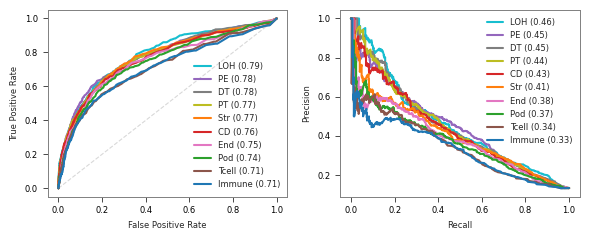

In [28]:
all_scores_pos =h5py.File(f"{kidzoi_score_dir}/pos/sad.h5")

all_scores_neg =h5py.File(f"{borzoi_score_dir}/neg/sad.h5")
sad, labels ,targets= compute_sad(all_scores_pos, all_scores_neg, pos_index, model='borzoi_rep')
plot_roc_pr_cells(labels, sad, cell_info,suptitle=None, save_pdf=True, filename="./fig_4c_and_d")

## plotting Kidformer auroc and auprc curves

Saved figure as ./fine_mapping_enformer


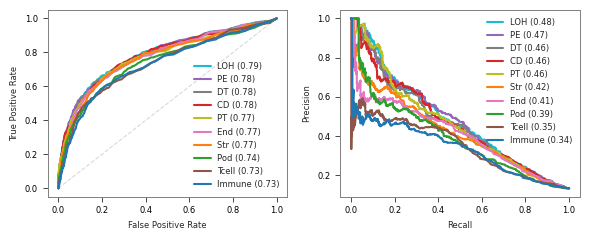

In [26]:
all_scores_pos =h5py.File(f"{kidformer_score_dir}/pos/sad.h5")
all_scores_neg =h5py.File(f"kidformer_score_dir}/sad.h5")
sad, labels, targets = compute_sad(all_scores_pos, all_scores_neg, pos_index,model='enformerfinetuned')
plot_roc_pr_cells(labels, sad, cell_info,suptitle=None, save_pdf=True, filename="./fine_mapping_enformer")

## plotting Chromkid auroc and auprc curves

In [31]:
all_scores_pos =h5py.File(f"{chromekid_score_dir}/pos/sad.h5")
all_scores_neg =h5py.File(f"{chromekid_score_dir}/neg_true_p_gt_o_1/sad.h5")

sadpos = all_scores_pos['SAD'][pos_index]
sadneg = all_scores_neg['SAD'][:]

labels = np.concatenate([np.ones(sadpos.shape[0]), np.zeros(sadneg.shape[0])])
sad_all = np.concatenate([sadpos, sadneg])
sad_all = np.abs(sad_all)
sad_all = np.abs(sad_all)

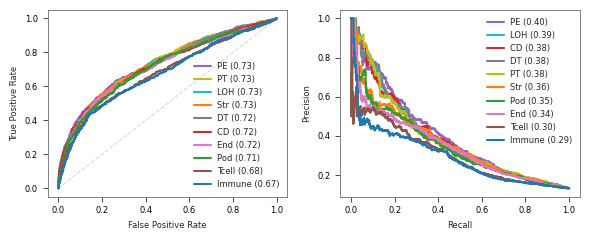

In [32]:
plot_roc_pr_cells(labels, sad_all, cell_info,suptitle=None, save_pdf=None, filename="./finemapping_chromekid")